In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

# CONFIG
DATA_DIR   = "../dataset/Garbage classification"
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS_CNN = 15
EPOCHS_TL  = 10
CLASSES    = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

In [2]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
    shuffle=False
)

print("Classes:", train_gen.class_indices)

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Classes: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [3]:
def build_custom_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(6, activation='softmax')
    ])
    return model

cnn_model = build_custom_cnn()
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

c:\Users\sachd\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,786,054 (98.37 MB)

 Trainable params: 25,785,606 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [4]:
cnn_history = cnn_model.fit(
    train_gen,
    epochs=EPOCHS_CNN,
    validation_data=val_gen
)

cnn_model.save("../models/custom_cnn.h5")

Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 178s 3s/step - accuracy: 0.3681 - loss: 13.2731 - val_accuracy: 0.1909 - val_loss: 38.6806
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.3118 - loss: 1.7384 - val_accuracy: 0.1610 - val_loss: 44.1656
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.2915 - loss: 1.7383 - val_accuracy: 0.1531 - val_loss: 33.6192
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 189s 3s/step - accuracy: 0.2955 - loss: 1.7129 - val_accuracy: 0.1451 - val_loss: 43.6726
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.2668 - loss: 1.7245 - val_accuracy: 0.1372 - val_loss: 20.7398
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 163s 3s/step - accuracy: 0.2821 - loss: 1.6857 - val_accuracy: 0.1889 - val_loss: 7.6141
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 151s 2s/step - accuracy: 0.2796 - loss: 1.7726 - val_accuracy: 0.2087 - val_loss: 3.4979
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 177s 3s/step - accuracy: 0.2856 - loss: 1.6789 - val_accuracy: 0.33

In [5]:
def build_transfer_model():
    base = MobileNetV2(
        input_shape=(224,224,3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(6, activation='softmax')
    ])
    return model, base

tl_model, base_model = build_transfer_model()

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [6]:
tl_model.fit(train_gen, epochs=5, validation_data=val_gen)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 911ms/step - accuracy: 0.4002 - loss: 1.5164 - val_accuracy: 0.5427 - val_loss: 1.2274
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.5904 - loss: 1.0881 - val_accuracy: 0.6243 - val_loss: 0.9989
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 62s 951ms/step - accuracy: 0.6670 - loss: 0.9022 - val_accuracy: 0.6421 - val_loss: 0.8880
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.6966 - loss: 0.8246 - val_accuracy: 0.6620 - val_loss: 0.8076
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 59s 925ms/step - accuracy: 0.7154 - loss: 0.7637 - val_accuracy: 0.6759 - val_loss: 0.7738


In [7]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_history = tl_model.fit(
    train_gen,
    epochs=EPOCHS_TL,
    validation_data=val_gen
)

tl_model.save("../models/mobilenet_v2.h5")

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.6369 - loss: 1.0344 - val_accuracy: 0.6779 - val_loss: 0.7905
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.6986 - loss: 0.8409 - val_accuracy: 0.6799 - val_loss: 0.8217
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.7268 - loss: 0.7620 - val_accuracy: 0.6779 - val_loss: 0.8202
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.7451 - loss: 0.7204 - val_accuracy: 0.6839 - val_loss: 0.8118
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.7554 - loss: 0.6690 - val_accuracy: 0.6958 - val_loss: 0.8084
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.7717 - loss: 0.6354 - val_accuracy: 0.7018 - val_loss: 0.7998
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.8063 - loss: 0.5871 - val_accuracy: 0.7038 - val_loss: 0.7957
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.8152 - loss: 0.5477 - val_accuracy: 0.7117 - val_loss

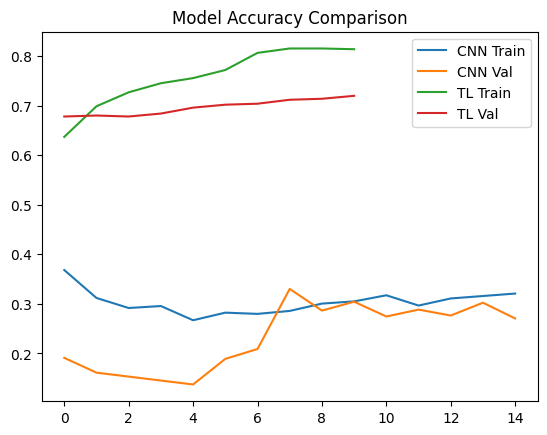

In [8]:
plt.plot(cnn_history.history['accuracy'], label='CNN Train')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val')
plt.plot(tl_history.history['accuracy'], label='TL Train')
plt.plot(tl_history.history['val_accuracy'], label='TL Val')
plt.legend()
plt.title("Model Accuracy Comparison")
plt.show()

In [9]:
def plot_confusion_matrix(model, generator, title):
    generator.reset()
    y_pred = model.predict(generator)
    y_pred_classes = np.argmax(y_pred, axis=1)
    y_true = generator.classes

    cm = confusion_matrix(y_true, y_pred_classes)

    sns.heatmap(cm, annot=True, fmt='d',
                xticklabels=CLASSES,
                yticklabels=CLASSES)
    plt.title(title)
    plt.show()

    print(classification_report(y_true, y_pred_classes, target_names=CLASSES))

16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 340ms/step


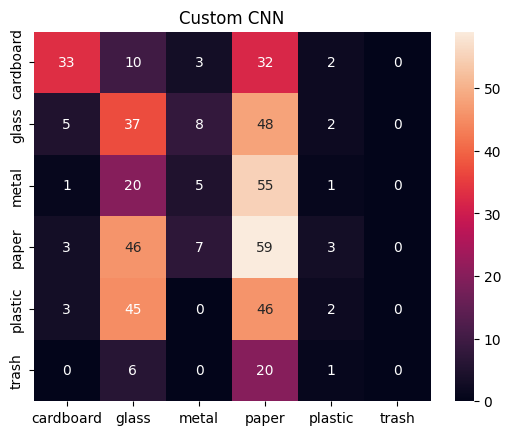

c:\Users\sachd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sachd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sachd\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

              precision    recall  f1-score   support

   cardboard       0.73      0.41      0.53        80
       glass       0.23      0.37      0.28       100
       metal       0.22      0.06      0.10        82
       paper       0.23      0.50      0.31       118
     plastic       0.18      0.02      0.04        96
       trash       0.00      0.00      0.00        27

    accuracy                           0.27       503
   macro avg       0.26      0.23      0.21       503
weighted avg       0.28      0.27      0.24       503

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 569ms/step


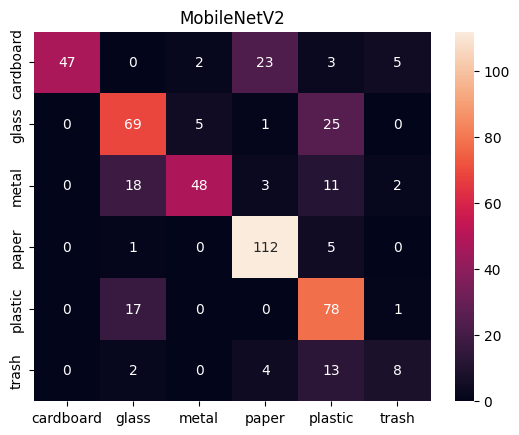

              precision    recall  f1-score   support

   cardboard       1.00      0.59      0.74        80
       glass       0.64      0.69      0.67       100
       metal       0.87      0.59      0.70        82
       paper       0.78      0.95      0.86       118
     plastic       0.58      0.81      0.68        96
       trash       0.50      0.30      0.37        27

    accuracy                           0.72       503
   macro avg       0.73      0.65      0.67       503
weighted avg       0.75      0.72      0.71       503



In [10]:
plot_confusion_matrix(cnn_model, val_gen, "Custom CNN")
plot_confusion_matrix(tl_model, val_gen, "MobileNetV2")